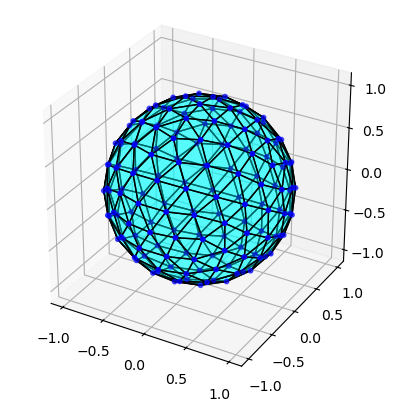

In [7]:
import numpy as np
from scipy.spatial import ConvexHull
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d.art3d import Poly3DCollection

# Function to create vertices of an icosahedron
def create_icosahedron():
    phi = (1 + np.sqrt(5)) / 2  # golden ratio
    
    # Create initial icosahedron vertices
    vertices = np.array([
        [-1,  phi, 0],
        [ 1,  phi, 0],
        [-1, -phi, 0],
        [ 1, -phi, 0],
        
        [0, -1,  phi],
        [0,  1,  phi],
        [0, -1, -phi],
        [0,  1, -phi],
        
        [ phi, 0, -1],
        [ phi, 0,  1],
        [-phi, 0, -1],
        [-phi, 0,  1],
    ])
    
    # Normalize to ensure all points are on the unit sphere
    vertices /= np.linalg.norm(vertices, axis=1)[:, np.newaxis]
    return vertices

# Function to refine each triangular face into smaller triangles
def subdivide_faces(vertices, faces, depth=1):
    vertices = vertices.tolist()  # Convert to list to dynamically add new vertices
    for _ in range(depth):
        new_faces = []
        midpoints = {}
        
        def midpoint(v1, v2):
            """Calculate the midpoint of two vertices on the unit sphere."""
            key = tuple(sorted((v1, v2)))
            if key not in midpoints:
                m = (np.array(vertices[v1]) + np.array(vertices[v2])) / 2
                m = m / np.linalg.norm(m)  # Normalize midpoint
                midpoints[key] = len(vertices)
                vertices.append(m.tolist())
            return midpoints[key]
        
        for face in faces:
            v1, v2, v3 = face
            # Create midpoints for each edge
            a = midpoint(v1, v2)
            b = midpoint(v2, v3)
            c = midpoint(v3, v1)
            # Create 4 new faces from the midpoints
            new_faces.extend([
                [v1, a, c],
                [v2, b, a],
                [v3, c, b],
                [a, b, c]
            ])
        
        faces = new_faces
    return np.array(vertices), np.array(faces)

# Create initial icosahedron vertices and faces
vertices = create_icosahedron()
faces = ConvexHull(vertices).simplices  # Get triangular faces from convex hull

# Subdivide faces for finer resolution (depth=1 for demonstration)
vertices, faces = subdivide_faces(vertices, faces, depth=2)

# Convert list to numpy array
vertices = np.array(vertices)

# Plot the icosahedral mesh
fig = plt.figure()
ax = fig.add_subplot(111, projection="3d")

# Plot each triangular face as a polygon
polygons = [vertices[face] for face in faces]
poly_collection = Poly3DCollection(polygons, color='cyan', edgecolor='k', alpha=0.4)
ax.add_collection3d(poly_collection)

# Plot vertices
ax.scatter(vertices[:, 0], vertices[:, 1], vertices[:, 2], color='b', s=10)

# Set plot limits
ax.set_box_aspect([1, 1, 1])
plt.show()


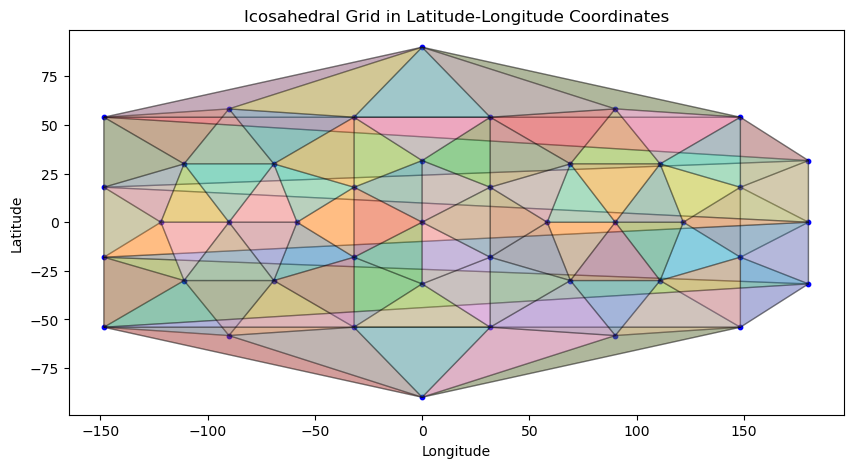

In [4]:
import numpy as np
from scipy.spatial import ConvexHull
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d.art3d import Poly3DCollection

# Function to create vertices of an icosahedron
def create_icosahedron():
    phi = (1 + np.sqrt(5)) / 2  # golden ratio
    
    # Create initial icosahedron vertices
    vertices = np.array([
        [-1,  phi, 0],
        [ 1,  phi, 0],
        [-1, -phi, 0],
        [ 1, -phi, 0],
        
        [0, -1,  phi],
        [0,  1,  phi],
        [0, -1, -phi],
        [0,  1, -phi],
        
        [ phi, 0, -1],
        [ phi, 0,  1],
        [-phi, 0, -1],
        [-phi, 0,  1],
    ])
    
    # Normalize to ensure all points are on the unit sphere
    vertices /= np.linalg.norm(vertices, axis=1)[:, np.newaxis]
    return vertices

# Function to refine each triangular face into smaller triangles
def subdivide_faces(vertices, faces, depth=1):
    vertices = vertices.tolist()  # Convert to list to dynamically add new vertices
    for _ in range(depth):
        new_faces = []
        midpoints = {}
        
        def midpoint(v1, v2):
            """Calculate the midpoint of two vertices on the unit sphere."""
            key = tuple(sorted((v1, v2)))
            if key not in midpoints:
                m = (np.array(vertices[v1]) + np.array(vertices[v2])) / 2
                m = m / np.linalg.norm(m)  # Normalize midpoint
                midpoints[key] = len(vertices)
                vertices.append(m.tolist())
            return midpoints[key]
        
        for face in faces:
            v1, v2, v3 = face
            # Create midpoints for each edge
            a = midpoint(v1, v2)
            b = midpoint(v2, v3)
            c = midpoint(v3, v1)
            # Create 4 new faces from the midpoints
            new_faces.extend([
                [v1, a, c],
                [v2, b, a],
                [v3, c, b],
                [a, b, c]
            ])
        
        faces = new_faces
    return np.array(vertices), np.array(faces)

# Convert Cartesian coordinates (x, y, z) to geographic (latitude, longitude)
def cartesian_to_latlon(vertices):
    latitudes = np.arcsin(vertices[:, 2]) * (180 / np.pi)  # z -> latitude
    longitudes = np.arctan2(vertices[:, 1], vertices[:, 0]) * (180 / np.pi)  # x, y -> longitude
    return latitudes, longitudes

# Create initial icosahedron vertices and faces
vertices = create_icosahedron()
faces = ConvexHull(vertices).simplices  # Get triangular faces from convex hull

# Subdivide faces for finer resolution (depth=1 for demonstration)
vertices, faces = subdivide_faces(vertices, faces, depth=1)

# Convert vertices to latitude and longitude
latitudes, longitudes = cartesian_to_latlon(vertices)

# Plot the icosahedral grid on a 2D map projection
plt.figure(figsize=(10, 5))
plt.scatter(longitudes, latitudes, color='b', s=10)

# Draw triangular faces
for face in faces:
    polygon_lons = longitudes[face]
    polygon_lats = latitudes[face]
    plt.fill(polygon_lons, polygon_lats, edgecolor='k', alpha=0.3)

plt.title("Icosahedral Grid in Latitude-Longitude Coordinates")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.show()


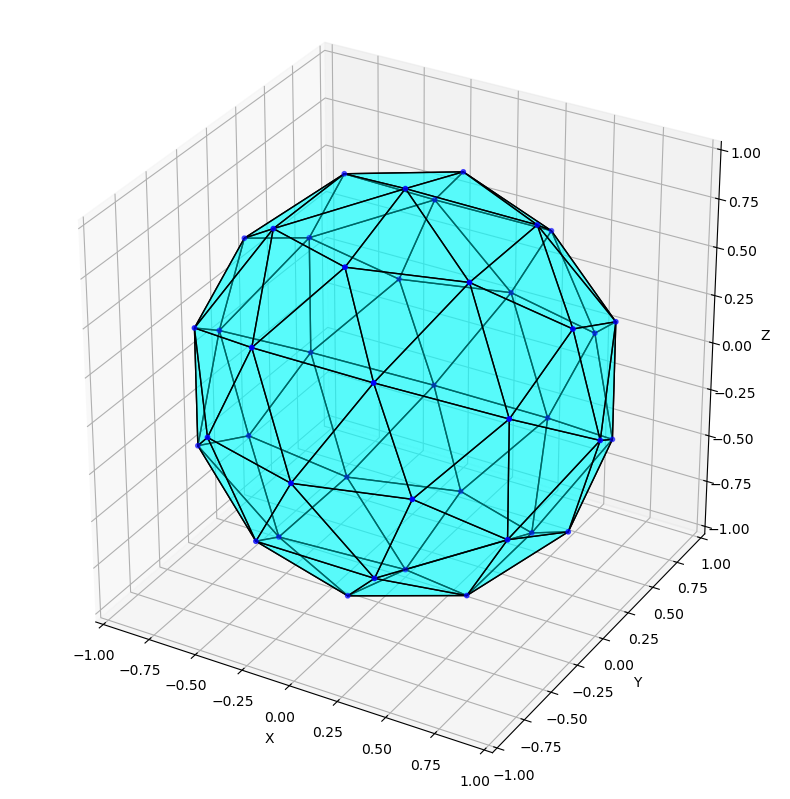

In [5]:
import numpy as np
from scipy.spatial import ConvexHull
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d.art3d import Poly3DCollection

# Function to create vertices of an icosahedron
def create_icosahedron():
    phi = (1 + np.sqrt(5)) / 2  # golden ratio
    
    # Create initial icosahedron vertices
    vertices = np.array([
        [-1,  phi, 0],
        [ 1,  phi, 0],
        [-1, -phi, 0],
        [ 1, -phi, 0],
        
        [0, -1,  phi],
        [0,  1,  phi],
        [0, -1, -phi],
        [0,  1, -phi],
        
        [ phi, 0, -1],
        [ phi, 0,  1],
        [-phi, 0, -1],
        [-phi, 0,  1],
    ])
    
    # Normalize to ensure all points are on the unit sphere
    vertices /= np.linalg.norm(vertices, axis=1)[:, np.newaxis]
    return vertices

# Function to refine each triangular face into smaller triangles
def subdivide_faces(vertices, faces, depth=1):
    vertices = vertices.tolist()  # Convert to list to dynamically add new vertices
    for _ in range(depth):
        new_faces = []
        midpoints = {}
        
        def midpoint(v1, v2):
            """Calculate the midpoint of two vertices on the unit sphere."""
            key = tuple(sorted((v1, v2)))
            if key not in midpoints:
                m = (np.array(vertices[v1]) + np.array(vertices[v2])) / 2
                m = m / np.linalg.norm(m)  # Normalize midpoint
                midpoints[key] = len(vertices)
                vertices.append(m.tolist())
            return midpoints[key]
        
        for face in faces:
            v1, v2, v3 = face
            # Create midpoints for each edge
            a = midpoint(v1, v2)
            b = midpoint(v2, v3)
            c = midpoint(v3, v1)
            # Create 4 new faces from the midpoints
            new_faces.extend([
                [v1, a, c],
                [v2, b, a],
                [v3, c, b],
                [a, b, c]
            ])
        
        faces = new_faces
    return np.array(vertices), np.array(faces)

# Create initial icosahedron vertices and faces
vertices = create_icosahedron()
faces = ConvexHull(vertices).simplices  # Get triangular faces from convex hull

# Subdivide faces for finer resolution (depth=1 for demonstration)
vertices, faces = subdivide_faces(vertices, faces, depth=1)

# Plot the icosahedral mesh on a 3D sphere
fig = plt.figure(figsize=(10, 10))
ax = fig.add_subplot(111, projection="3d")

# Plot each triangular face as a polygon on the sphere
polygons = [vertices[face] for face in faces]
poly_collection = Poly3DCollection(polygons, color='cyan', edgecolor='k', alpha=0.4)
ax.add_collection3d(poly_collection)

# Plot vertices on the sphere
ax.scatter(vertices[:, 0], vertices[:, 1], vertices[:, 2], color='b', s=10)

# Set equal scaling for all axes
ax.set_box_aspect([1, 1, 1])

# Set limits and labels
ax.set_xlim([-1, 1])
ax.set_ylim([-1, 1])
ax.set_zlim([-1, 1])
ax.set_xlabel("X")
ax.set_ylabel("Y")
ax.set_zlabel("Z")

plt.show()


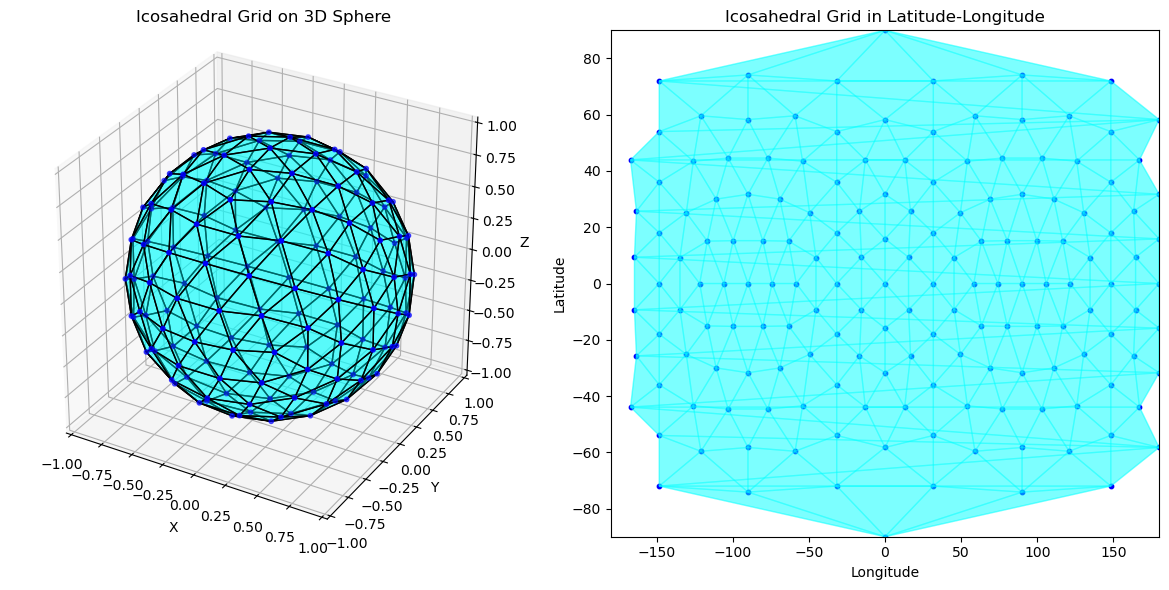

In [9]:
import numpy as np
from scipy.spatial import ConvexHull
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d.art3d import Poly3DCollection

# Function to create vertices of an icosahedron
def create_icosahedron():
    phi = (1 + np.sqrt(5)) / 2  # golden ratio
    
    # Create initial icosahedron vertices
    vertices = np.array([
        [-1,  phi, 0],
        [ 1,  phi, 0],
        [-1, -phi, 0],
        [ 1, -phi, 0],
        
        [0, -1,  phi],
        [0,  1,  phi],
        [0, -1, -phi],
        [0,  1, -phi],
        
        [ phi, 0, -1],
        [ phi, 0,  1],
        [-phi, 0, -1],
        [-phi, 0,  1],
    ])
    
    # Normalize to ensure all points are on the unit sphere
    vertices /= np.linalg.norm(vertices, axis=1)[:, np.newaxis]
    return vertices

# Function to refine each triangular face into smaller triangles
def subdivide_faces(vertices, faces, depth=1):
    vertices = vertices.tolist()  # Convert to list to dynamically add new vertices
    for _ in range(depth):
        new_faces = []
        midpoints = {}
        
        def midpoint(v1, v2):
            """Calculate the midpoint of two vertices on the unit sphere."""
            key = tuple(sorted((v1, v2)))
            if key not in midpoints:
                m = (np.array(vertices[v1]) + np.array(vertices[v2])) / 2
                m = m / np.linalg.norm(m)  # Normalize midpoint
                midpoints[key] = len(vertices)
                vertices.append(m.tolist())
            return midpoints[key]
        
        for face in faces:
            v1, v2, v3 = face
            # Create midpoints for each edge
            a = midpoint(v1, v2)
            b = midpoint(v2, v3)
            c = midpoint(v3, v1)
            # Create 4 new faces from the midpoints
            new_faces.extend([
                [v1, a, c],
                [v2, b, a],
                [v3, c, b],
                [a, b, c]
            ])
        
        faces = new_faces
    return np.array(vertices), np.array(faces)

# Convert Cartesian coordinates (x, y, z) to geographic (latitude, longitude)
def cartesian_to_latlon(vertices):
    latitudes = np.arcsin(vertices[:, 2]) * (180 / np.pi)  # z -> latitude
    longitudes = np.arctan2(vertices[:, 1], vertices[:, 0]) * (180 / np.pi)  # x, y -> longitude
    return latitudes, longitudes

# Create initial icosahedron vertices and faces
vertices = create_icosahedron()
faces = ConvexHull(vertices).simplices  # Get triangular faces from convex hull

# Subdivide faces for finer resolution (depth=1 for demonstration)
vertices, faces = subdivide_faces(vertices, faces, depth=2)

# Convert vertices to latitude and longitude
latitudes, longitudes = cartesian_to_latlon(vertices)

# Plot both 3D sphere and 2D map projection
fig = plt.figure(figsize=(12, 6))

# 3D Sphere Plot
ax1 = fig.add_subplot(121, projection="3d")
polygons = [vertices[face] for face in faces]
poly_collection = Poly3DCollection(polygons, color='cyan', edgecolor='k', alpha=0.4)
ax1.add_collection3d(poly_collection)
ax1.scatter(vertices[:, 0], vertices[:, 1], vertices[:, 2], color='b', s=10)
ax1.set_box_aspect([1, 1, 1])
ax1.set_xlim([-1, 1])
ax1.set_ylim([-1, 1])
ax1.set_zlim([-1, 1])
ax1.set_title("Icosahedral Grid on 3D Sphere")
ax1.set_xlabel("X")
ax1.set_ylabel("Y")
ax1.set_zlabel("Z")

# 2D Map Projection Plot
ax2 = fig.add_subplot(122)
ax2.scatter(longitudes, latitudes, color='b', s=10)
for face in faces:
    polygon_lons = longitudes[face]
    polygon_lats = latitudes[face]
    ax2.fill(polygon_lons, polygon_lats, edgecolor='k', alpha=0.3, color='cyan')
ax2.set_title("Icosahedral Grid in Latitude-Longitude")
ax2.set_xlabel("Longitude")
ax2.set_ylabel("Latitude")
ax2.set_xlim([-180, 180])
ax2.set_ylim([-90, 90])

plt.tight_layout()
plt.show()


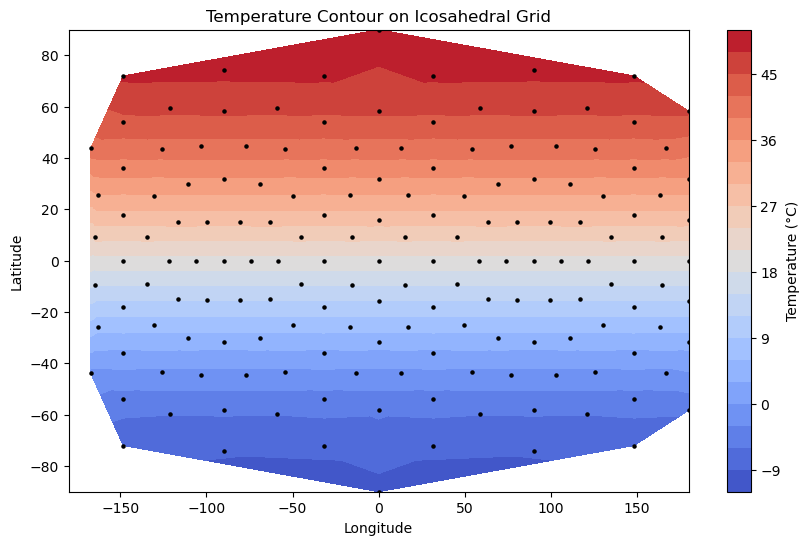

In [12]:
# Generate synthetic temperature data for each vertex (for demonstration)
temperature_data = np.sin(np.radians(latitudes)) * 30 + 20  # A temperature-like distribution

# Plot the contour of temperature data on a 2D map
plt.figure(figsize=(10, 6))
contour = plt.tricontourf(longitudes, latitudes, temperature_data, levels=20, cmap="coolwarm")
plt.colorbar(contour, label="Temperature (°C)")
plt.scatter(longitudes, latitudes, color='k', s=5)  # Plot points to show grid locations
plt.title("Temperature Contour on Icosahedral Grid")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.xlim([-180, 180])
plt.ylim([-90, 90])
plt.show()

In [13]:
import cartopy.crs as ccrs
import cartopy.feature as cfeature

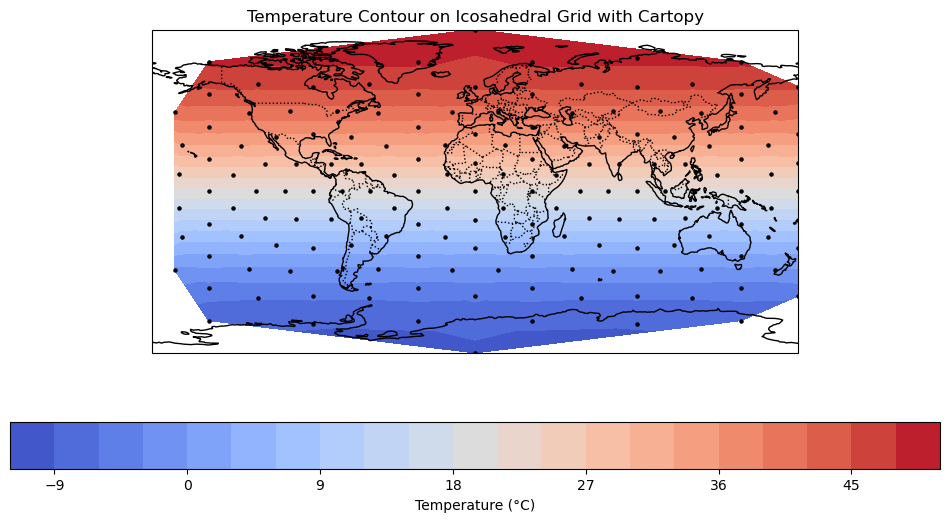

In [14]:
# Plotting with cartopy
fig = plt.figure(figsize=(12, 6))
ax = plt.axes(projection=ccrs.PlateCarree())
ax.set_global()
ax.add_feature(cfeature.COASTLINE)
ax.add_feature(cfeature.BORDERS, linestyle=':')

# Plot contours with cartopy
contour = ax.tricontourf(longitudes, latitudes, temperature_data, levels=20, cmap="coolwarm", transform=ccrs.PlateCarree())
plt.colorbar(contour, ax=ax, orientation="horizontal", label="Temperature (°C)")

# Optional: Scatter points to show grid locations
ax.scatter(longitudes, latitudes, color='k', s=5, transform=ccrs.PlateCarree())

ax.set_title("Temperature Contour on Icosahedral Grid with Cartopy")
plt.show()

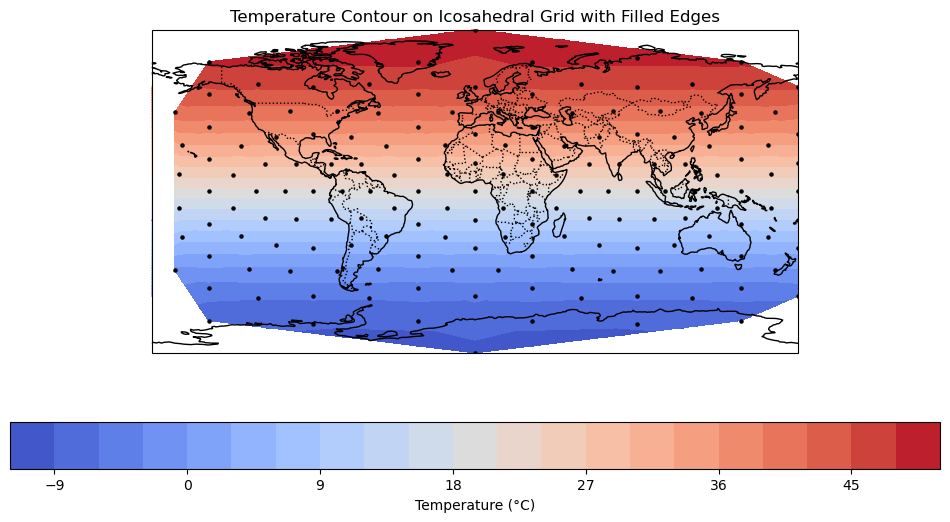

In [16]:
import numpy as np
from scipy.spatial import ConvexHull
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature

# Assuming latitudes, longitudes, and temperature_data have been generated

# Plotting with cartopy
fig = plt.figure(figsize=(12, 6))
ax = plt.axes(projection=ccrs.PlateCarree())
ax.set_global()
ax.add_feature(cfeature.COASTLINE)
ax.add_feature(cfeature.BORDERS, linestyle=':')

# Option 1: Set background color for unplotted areas
#ax.background_patch.set_facecolor("lightgrey")

# Option 2: Add a filled base layer using pcolormesh (smooth interpolation)
# Define a grid for interpolation (e.g., 1-degree resolution)
lon_grid = np.linspace(-180, 180, 360)
lat_grid = np.linspace(-90, 90, 180)
lon_grid, lat_grid = np.meshgrid(lon_grid, lat_grid)
# Interpolate the temperature data onto the grid
from scipy.interpolate import griddata
temperature_grid = griddata((longitudes, latitudes), temperature_data, (lon_grid, lat_grid), method='linear')
# Plot the filled base layer
mesh = ax.pcolormesh(lon_grid, lat_grid, temperature_grid, cmap="coolwarm", shading='auto', transform=ccrs.PlateCarree())

# Plot contours on top of the filled layer
contour = ax.tricontourf(longitudes, latitudes, temperature_data, levels=20, cmap="coolwarm", transform=ccrs.PlateCarree())
plt.colorbar(contour, ax=ax, orientation="horizontal", label="Temperature (°C)")

# Optional: Scatter points to show grid locations
ax.scatter(longitudes, latitudes, color='k', s=5, transform=ccrs.PlateCarree())

ax.set_title("Temperature Contour on Icosahedral Grid with Filled Edges")
plt.show()


In [17]:
import numpy as np
from scipy.spatial import ConvexHull

# Function to calculate spherical excess area of a triangle on a unit sphere
def triangle_area_on_sphere(v1, v2, v3):
    # Normalize vertices to ensure they are on the unit sphere
    v1 = v1 / np.linalg.norm(v1)
    v2 = v2 / np.linalg.norm(v2)
    v3 = v3 / np.linalg.norm(v3)
    
    # Calculate angles between each pair of vertices
    a = np.arccos(np.dot(v1, v2))
    b = np.arccos(np.dot(v2, v3))
    c = np.arccos(np.dot(v3, v1))
    
    # Spherical excess formula for area
    spherical_excess = a + b + c - np.pi
    area = spherical_excess  # On unit sphere, R^2 = 1
    return area

# Create initial icosahedron vertices and faces
def create_icosahedron():
    phi = (1 + np.sqrt(5)) / 2  # golden ratio
    
    vertices = np.array([
        [-1,  phi, 0],
        [ 1,  phi, 0],
        [-1, -phi, 0],
        [ 1, -phi, 0],
        
        [0, -1,  phi],
        [0,  1,  phi],
        [0, -1, -phi],
        [0,  1, -phi],
        
        [ phi, 0, -1],
        [ phi, 0,  1],
        [-phi, 0, -1],
        [-phi, 0,  1],
    ])
    
    vertices /= np.linalg.norm(vertices, axis=1)[:, np.newaxis]
    return vertices

vertices = create_icosahedron()
faces = ConvexHull(vertices).simplices  # Get triangular faces from convex hull

# Calculate the area for each triangular face
triangle_areas = []
for face in faces:
    v1, v2, v3 = vertices[face]
    area = triangle_area_on_sphere(v1, v2, v3)
    triangle_areas.append(area)

# Sum of all areas should approximate the surface area of a unit sphere (4π)
total_area = np.sum(triangle_areas)
print("Total Surface Area:", total_area)


Total Surface Area: 3.597069995849562
